In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

from tqdm import tqdm

import fiona

In [2]:
# path and name of geopackage file
filename = 'TSRA_v2.gpkg'

In [3]:
# identify layers in geopackage
layers = fiona.listlayers(filename)
print (layers)

['shorelines_annual_1988-2025', 'rates_of_change_2021-2025', 'rates_of_change_1988-2025', 'shorelines_annual_1988-2020', 'rates_of_change_2016-2020', 'rates_of_change_1988-2020', 'shorelines_annual_1988-2015', 'rates_of_change_2011-2015', 'rates_of_change_1988-2015', 'shorelines_annual_1988-2010', 'rates_of_change_2006-2010', 'rates_of_change_1988-2010', 'shorelines_annual_1988-2005', 'rates_of_change_2001-2005', 'rates_of_change_1988-2005', 'shorelines_annual_1988-2000', 'rates_of_change_1996-2000', 'rates_of_change_1988-2000']


In [4]:
# identify epoch of interest
epoch = '1988-2020'

# identify all rates of change layers
rates = []
for layer in layers:
    if layer.split('_')[0] == 'rates':
        rates.append(layer)

# identify rates of change layer for epoch of interest
for e in rates:
    if e.split('_')[-1] == epoch:
        rate = e

# read the gpkg layer for the epoch of interest
gdf = gpd.read_file(filename, layer=rate)

In [ ]:
# Get all dist_ columns
dist_cols = [col for col in gdf.columns if col.startswith('dist_')]
dist_cols.sort(key=lambda x: int(x.split('_')[1]))

print(f"Found {len(dist_cols)} distance fields: {dist_cols[0]} to {dist_cols[-1]}")
print(f"Processing {len(gdf)} features...")


# Process all rows with progress bar
print("\nProcessing features...")
tqdm.pandas()
results = gdf.progress_apply(process_row, axis=1)

# Add results to geopandas dataframe
gdf['r2_linear'] = results['r2_linear']
gdf['r2_cubic'] = results['r2_cubic']
# gdf['is_nonlinear_0.5'] = results['is_nonlinear']

# Calculate R² difference
gdf['r2_improvement'] = gdf['r2_cubic'] - gdf['r2_linear']
gdf['extreme_nonlinear'] = gdf['r2_improvement'] > 0.5

# Look at the distribution
print("R² Improvement Statistics:")
print(gdf['r2_improvement'].describe())

# Flag extreme non-linearity when r2_improvement (R2-diff) > 0.5
# Calculate quantile at 0.5 for record-keeping
n_below = (gdf['r2_improvement'] <= 0.5).sum()
n_total = gdf['r2_improvement'].notna().sum()
quantile = n_below / n_total

# Summary statistics
print(f"\n{'='*60}")
print(f"Processing complete!")
print(f"\nNon-linear points are flagged when r2_improvement > 0.5, the {quantile*100:.2f} percentile)")
print(f"Non-linear feature count (top {100 - quantile*100:.3f} %): {gdf['extreme_nonlinear'].sum()}")
print(f"Successfully processed: {results['r2_linear'].notna().sum()} features")
print(f"Skipped (insufficient data): {results['r2_linear'].isna().sum()} features")
print(f"{'='*60}")

# Optional: Save to file (preserves geometry)
gdf.to_file(f'{filename.split(".")[0]}_with_nonlinearity.gpkg', driver='GPKG')

# Calculating the portion of non-linear points in the stable and dynamic portions

nonlin=gdf[gdf['extreme_nonlinear']==True]

# Extreme non-linear points in dynamic fraction
nonlinA = nonlin[nonlin[f'sig_time_{epoch}']<0.01]
nonlin_dynamic = nonlinA[nonlinA['certainty']=='good']

# Total dynamic points
dynamicA = gdf[gdf[f'sig_time_{epoch}']<0.01]
dynamic = dynamicA[dynamicA['certainty']=='good']

# Total stable points
stable = len(gdf)-len(dynamic)

# Extreme non-linear points in stable fraction
nonlinB = nonlin[nonlin[f'sig_time_{epoch}']>=0.01]
nonlin_stable = nonlinB[nonlinB['certainty']!= 'good']

# Other non-linear points
nonlinC = nonlinA[nonlinA['certainty']!='good']
nonlinD = nonlinB[nonlinB['certainty']=='good']

print(f'For {epoch} over the whole of the Torres Strait:')
print(f'\nFraction of non-linear points overall: {gdf["extreme_nonlinear"].sum()/len(gdf)*100:.2f} %')
print(f'Non-linear points in the dynamic fraction: {len(nonlin_dynamic)}/{len(dynamic)} ({len(nonlin_dynamic)/len(dynamic)*100:.2f} %)')
print(f'Non-linear points in the stable fraction: {len(nonlin_stable)}/{stable} ({len(nonlin_stable)/stable*100:.2f} %)')
print(f"{'='*60}")

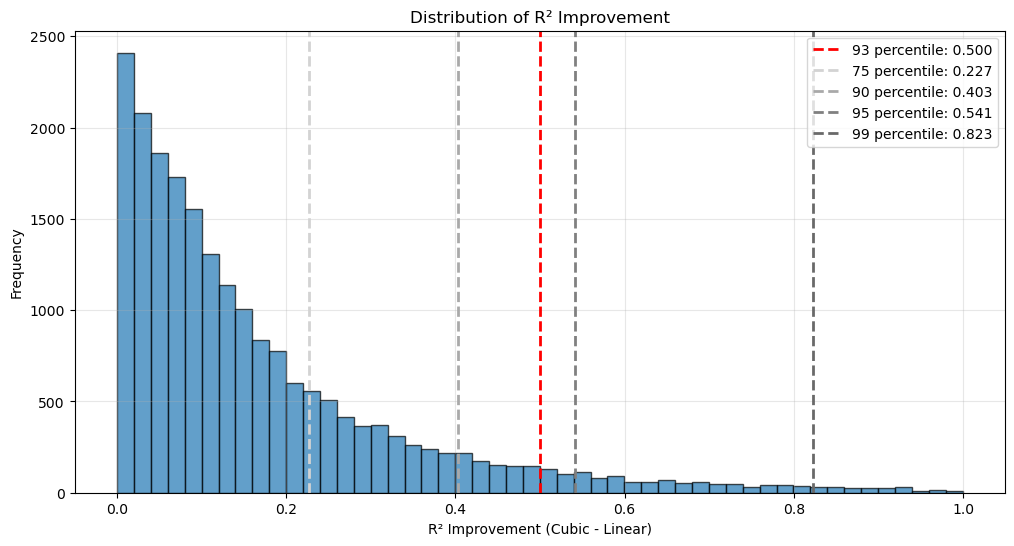

In [31]:
# View the distribution of R2

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(gdf['r2_improvement'].dropna(), bins=50, edgecolor='black', alpha=0.7)

# Add vertical lines for quantiles
quantiles = [quantile, 0.75, 0.90, 0.95, 0.99]
colors = ['red','lightgray', 'darkgray', 'gray', 'dimgray']

for q, color in zip(quantiles, colors):
    q_value = gdf['r2_improvement'].quantile(q)
    plt.axvline(q_value, color=color, linestyle='--', linewidth=2, 
                label=f'{int(q*100)} percentile: {q_value:.3f}')

plt.xlabel('R² Improvement (Cubic - Linear)')
plt.ylabel('Frequency')
plt.title('Distribution of R² Improvement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()